In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [98]:
df = pd.read_csv("dataset/dataset_regressao_polinomial.csv")

while True:

    anterior = len(df)

    q25 = df[df.columns[-1]].quantile(0.25)
    q75 = df[df.columns[-1]].quantile(0.75)

    iqr = q75 - q25

    li = q25 - 1.5 * iqr
    ls = q75 + 1.5 * iqr

    df = df[(df[df.columns[-1]] <= ls) & (df[df.columns[-1]] >= li)]

    apos = len(df)

    if anterior == apos:
        break

print(len(df))


993


In [99]:
x = df.drop(columns=df.columns[-1])
y = pd.DataFrame(df[df.columns[-1]])

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

x = poly.fit_transform(x)

x_tr, x_te, y_tr, y_te = train_test_split(x, y, train_size=0.8, random_state=42) 

In [101]:
from sklearn.linear_model import Ridge
modelo = Ridge(alpha=0.1)

c:\Users\pedro\Projetos\PYTHON\regressão-scikit-learn\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


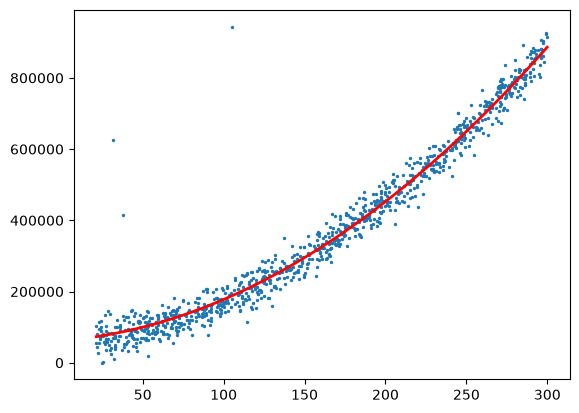

In [102]:
modelo.fit(x_tr, y_tr)

# Cria vários valores de área igualmente espaçados
x_linha = np.linspace(
    x[:, 1].min(),
    x[:, 1].max(),
    500
).reshape(-1, 1)

# Aplica a mesma transformação polinomial
x_linha_poly = poly.transform(x_linha)

# Faz a previsão da curva inteira
y_linha = modelo.predict(x_linha_poly)

# Desenha
plt.scatter(x[:, 1], y, s=2)
plt.plot(x_linha, y_linha, color="red", linewidth=2)

plt.show()

In [103]:
print("R2 =", modelo.score(x_te , y_te))

R2 = 0.98703846247445
